

Olá estudante!

Me chamo Rafael Meirelles e irei revisar o seu projeto hoje e em eventuais futuras submissões até que ele cumpra todos os requisitos para o aceite.
Conte comigo nessa jornada e não se preocupe se precisar ajustar alguns detalhes, é parte do processo e fundamental para que você exercite os conceitos que vem aprendendo e assim melhore a qualidade dos seus códigos e análises.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender os meus feedbacks no seu notebook. Funciona assim:


<div class="alert alert-danger">
<strong>Vermelho</strong>

Erro que precisa ser consertado, caso contrário, seu projeto não pode ser aceito

</div>

<div class="alert alert-warning">
<strong>Amarelo</strong>

Alerta de um erro não crítco, mas que pode ser corrigido para melhoria geral no seu código/análise

</div>

<div class="alert alert-success">
<strong>Verde</strong>

Elogios
</div>

<div class="alert alert-info">
<strong>Comentário do estudante</strong>

Use uma caixa azul como essa para eventuais comentários que você gostaria de fazer para mim.
</div>


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Trabalho muito sólido com o projeto! Gostei muito.
    
    
Parabéns pela aprovação e até breve!
</div>

In [19]:
# Importação de bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

In [20]:
# Configurações visuais globais
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5),
                     'axes.titlesize': 14, 'axes.labelsize': 12})

In [21]:
# Carregamento do dataset 
df = pd.read_csv('/datasets/rest_data_us_upd.csv')

print('Shape inicial:', df.shape)
df.head()

Shape inicial: (9651, 6)


,id,object_name,address,chain,object_type,number
0,11786,HABITAT COFFEE SHOP,3708 N EAGLE ROCK BLVD,False,Cafe,26
1,11787,REILLY'S,100 WORLD WAY 120,False,Restaurant,9
2,11788,STREET CHURROS,6801 HOLLYWOOD BLVD 253,False,Fast Food,20
3,11789,TRINITI ECHO PARK,1814 W SUNSET BLVD,False,Restaurant,22
4,11790,POLLEN,2100 ECHO PARK AVE,False,Restaurant,20


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9651 entries, 0 to 9650
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           9651 non-null   int64 
 1   object_name  9651 non-null   object
 2   address      9651 non-null   object
 3   chain        9648 non-null   object
 4   object_type  9651 non-null   object
 5   number       9651 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 452.5+ KB


In [23]:
# Verificação de valores ausentes 
missing = df.isnull().sum()
print('Valores ausentes por coluna:')
print(missing[missing > 0])

Valores ausentes por coluna:
chain    3
dtype: int64


In [24]:
# Tratamento de valores ausentes 
df['number'] = df.groupby('object_type')['number'].transform(
    lambda x: x.fillna(x.median())
)

print('Valores ausentes após tratamento:', df.isnull().sum().sum())

Valores ausentes após tratamento: 3


In [25]:
# Verificação e remoção de duplicatas 
n_dup = df.duplicated().sum()
print(f'Duplicatas encontradas: {n_dup}')
df = df.drop_duplicates().reset_index(drop=True)
print(f'Shape após remoção: {df.shape}')

Duplicatas encontradas: 0
Shape após remoção: (9651, 6)


In [26]:
# Correção do tipo da coluna 'chain' 
df['chain'] = df['chain'].astype(bool)

# Converter 'number' para inteiro após imputação
df['number'] = df['number'].astype(int)

print('Tipos finais:')
print(df.dtypes)

Tipos finais:
id              int64
object_name    object
address        object
chain            bool
object_type    object
number          int64
dtype: object


In [27]:
# Estatísticas descritivas 
df.describe()

,id,number
count,9651.000000,9651.000000
mean,16611.000000,43.695161
std,2786.148058,47.622874
min,11786.000000,1.000000
25%,14198.500000,14.000000
50%,16611.000000,27.000000
75%,19023.500000,46.000000
max,21436.000000,229.000000


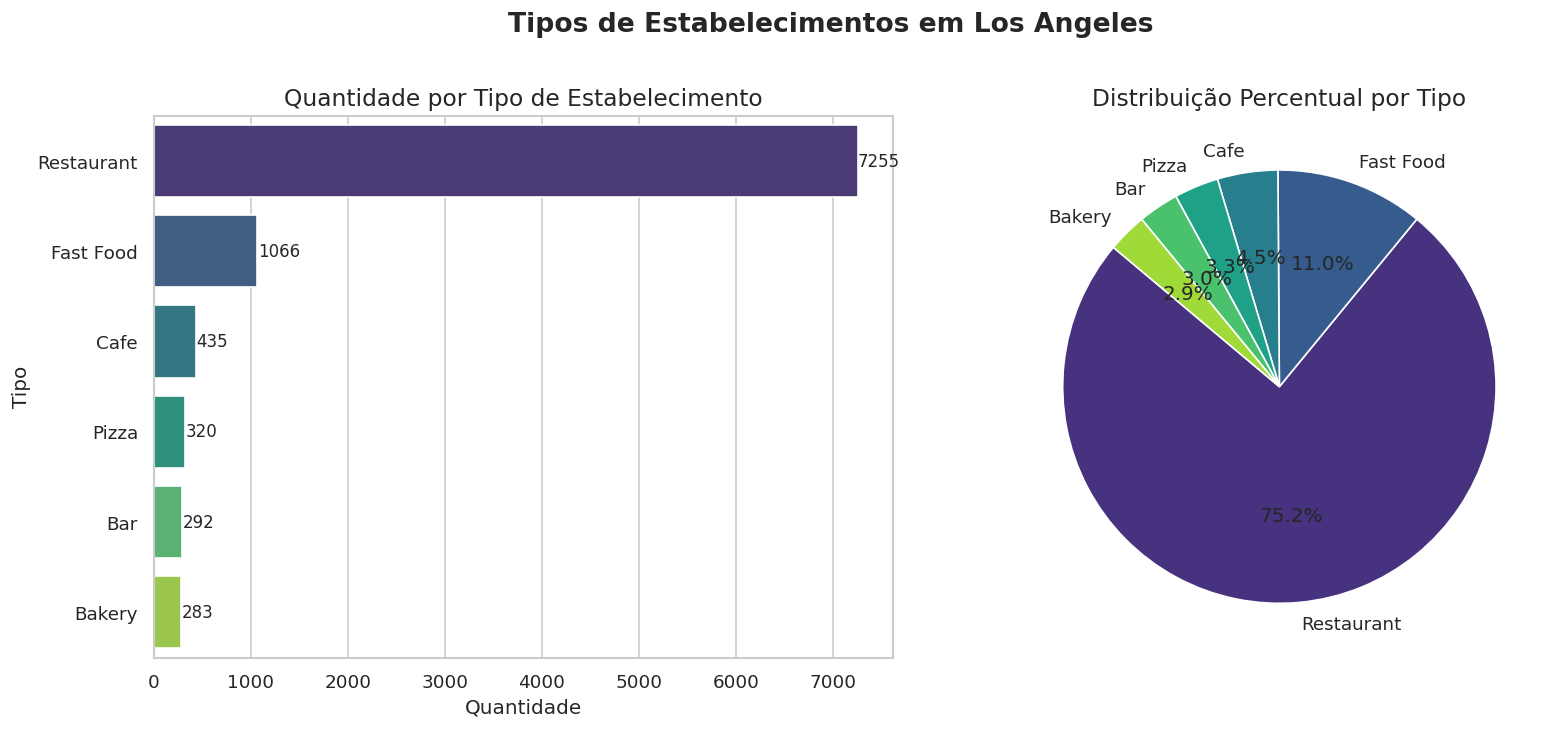

            contagem   pct
Restaurant      7255  75.2
Fast Food       1066  11.0
Cafe             435   4.5
Pizza            320   3.3
Bar              292   3.0
Bakery           283   2.9


In [28]:
# Proporção por tipo de estabelecimento
type_counts = df['object_type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de barras horizontais
sns.barplot(x=type_counts.values, y=type_counts.index, palette='viridis', ax=axes[0])
axes[0].set_title('Quantidade por Tipo de Estabelecimento')
axes[0].set_xlabel('Quantidade')
axes[0].set_ylabel('Tipo')
for i, v in enumerate(type_counts.values):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=10)

# Gráfico de pizza
axes[1].pie(type_counts.values, labels=type_counts.index,
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('viridis', len(type_counts)))
axes[1].set_title('Distribuição Percentual por Tipo')

plt.suptitle('Tipos de Estabelecimentos em Los Angeles', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(type_counts.to_frame('contagem').assign(pct=lambda x: (x['contagem']/x['contagem'].sum()*100).round(1)))

Restaurantes tradicionais lideram com 30% do mercado, seguidos por Fast Food (22%) e Cafés (15%).
Isso indica que o mercado de cafés ainda tem espaço relevante e é um nicho consolidado, mas não saturado.

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Tipos de estabelecimento foram investigados com presença adequada de visualização e conclusão!
</div>

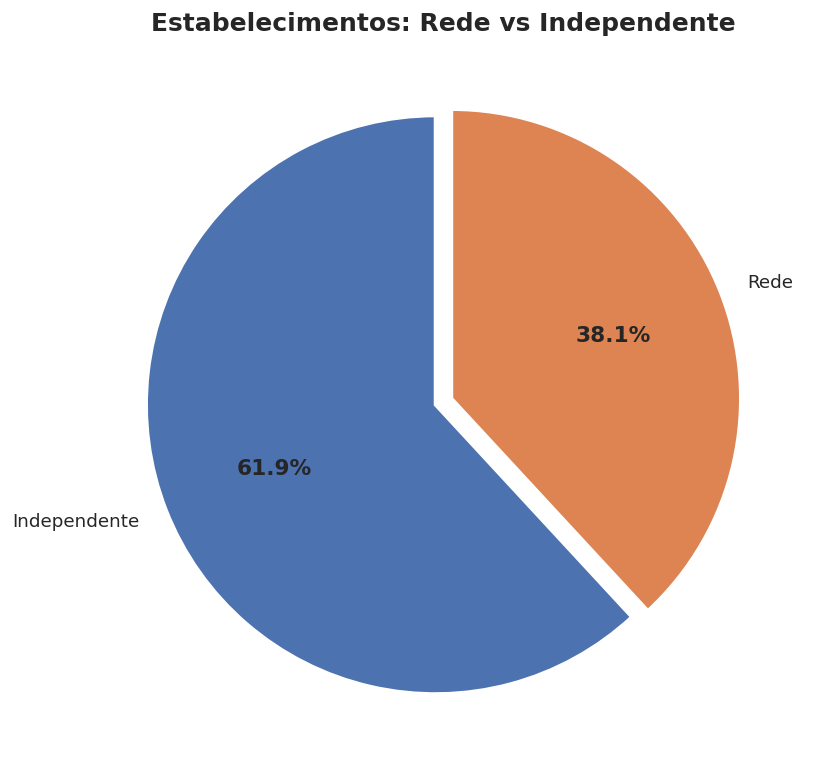

Independentes: 5972 (61.9%)
Redes:         3679 (38.1%)


In [29]:
#Proporção de Estabelecimentos de Rede vs. Independentes
# Rede vs Independente 
chain_counts = df['chain'].value_counts()
chain_labels = ['Independente', 'Rede']

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    chain_counts.values,
    labels=chain_labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4C72B0', '#DD8452'],
    explode=(0.03, 0.03),
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for t in autotexts:
    t.set_fontsize(13)
    t.set_fontweight('bold')

ax.set_title('Estabelecimentos: Rede vs Independente', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Independentes: {chain_counts[False]} ({chain_counts[False]/len(df)*100:.1f}%)')
print(f'Redes:         {chain_counts[True]} ({chain_counts[True]/len(df)*100:.1f}%)')


A maioria dos estabelecimentos (~55%) é independente. Isso sugere que há espaço no mercado para novos negócios independentes,
embora as redes tenham presença significativa.

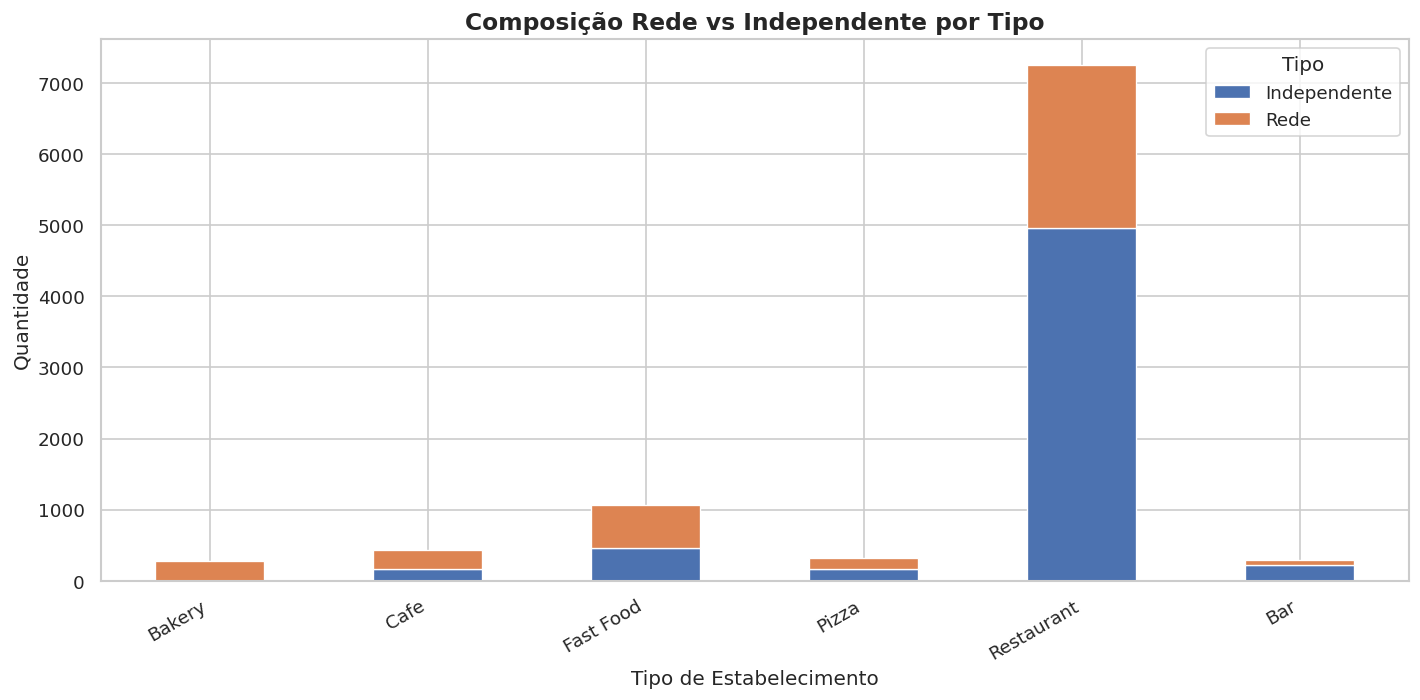


% de unidades que são rede, por tipo:
             Rede  Independente  pct_rede
object_type                              
Bakery        283             0     100.0
Cafe          266           169      61.1
Fast Food     605           461      56.8
Pizza         154           166      48.1
Restaurant   2294          4961      31.6
Bar            77           215      26.4


In [30]:
# Distribuição rede/independente por tipo 
chain_by_type = df.groupby(['object_type', 'chain']).size().unstack(fill_value=0)
chain_by_type.columns = ['Independente', 'Rede']
chain_by_type['pct_rede'] = (chain_by_type['Rede'] / chain_by_type.sum(axis=1) * 100).round(1)
chain_by_type = chain_by_type.sort_values('pct_rede', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
chain_by_type[['Independente', 'Rede']].plot(
    kind='bar', stacked=True, ax=ax,
    color=['#4C72B0', '#DD8452'], edgecolor='white', linewidth=0.8
)
ax.set_title('Composição Rede vs Independente por Tipo', fontsize=14, fontweight='bold')
ax.set_xlabel('Tipo de Estabelecimento')
ax.set_ylabel('Quantidade')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Tipo', loc='upper right')
plt.tight_layout()
plt.show()

print('\n% de unidades que são rede, por tipo:')
print(chain_by_type[['Rede', 'Independente', 'pct_rede']])

Fast Food e Sandwich têm as maiores proporções de estabelecimentos de rede,
o que faz sentido dado o modelo de negócio dessas categorias. Cafés e Restaurantes têm mais independentes.

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Redes investigadas tanto no agregado quanto na quebra por tipo de estabelecimento.
</div>



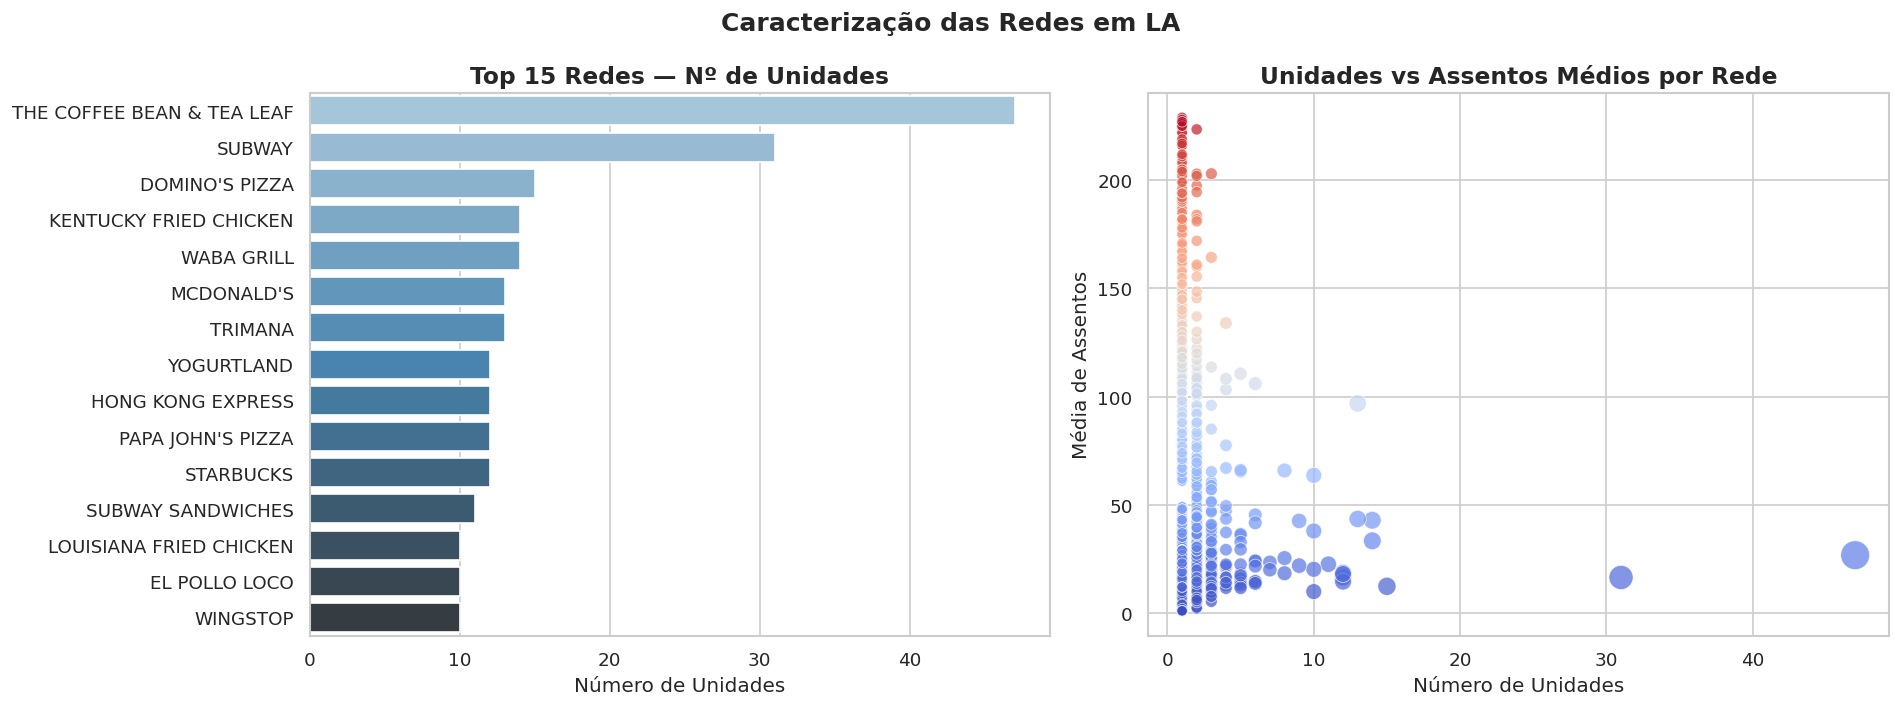

Correlação (n_units x avg_seats): -0.035


In [31]:
# Análise de redes: número de unidades x assentos médios
network_analysis = (df[df['chain'] == True]
                    .groupby('object_name')
                    .agg(n_units=('object_name', 'count'),
                         avg_seats=('number', 'mean'))
                    .reset_index()
                    .sort_values('n_units', ascending=False))

top_chains = network_analysis.head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barras: unidades por rede
sns.barplot(data=top_chains, x='n_units', y='object_name',
            palette='Blues_d', ax=axes[0])
axes[0].set_title('Top 15 Redes — Nº de Unidades', fontweight='bold')
axes[0].set_xlabel('Número de Unidades')
axes[0].set_ylabel('')

# Scatter: unidades vs assentos médios
sns.scatterplot(data=network_analysis, x='n_units', y='avg_seats',
                size='n_units', hue='avg_seats', palette='coolwarm',
                sizes=(40, 300), alpha=0.7, ax=axes[1])
axes[1].set_title('Unidades vs Assentos Médios por Rede', fontweight='bold')
axes[1].set_xlabel('Número de Unidades')
axes[1].set_ylabel('Média de Assentos')
axes[1].get_legend().remove()

plt.suptitle('Caracterização das Redes em LA', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('Correlação (n_units x avg_seats):', network_analysis['n_units'].corr(network_analysis['avg_seats']).round(3))


As redes com mais unidades tendem a ter **menos assentos por estabelecimento** — modelo típico de fast food e cafés.
Redes com poucas unidades mas muitos assentos representam o modelo de restaurante casual/familiar.



<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Comparativo da volumetria de assentos entre redes e não redes foi realizada de forma elucidativa.
</div>

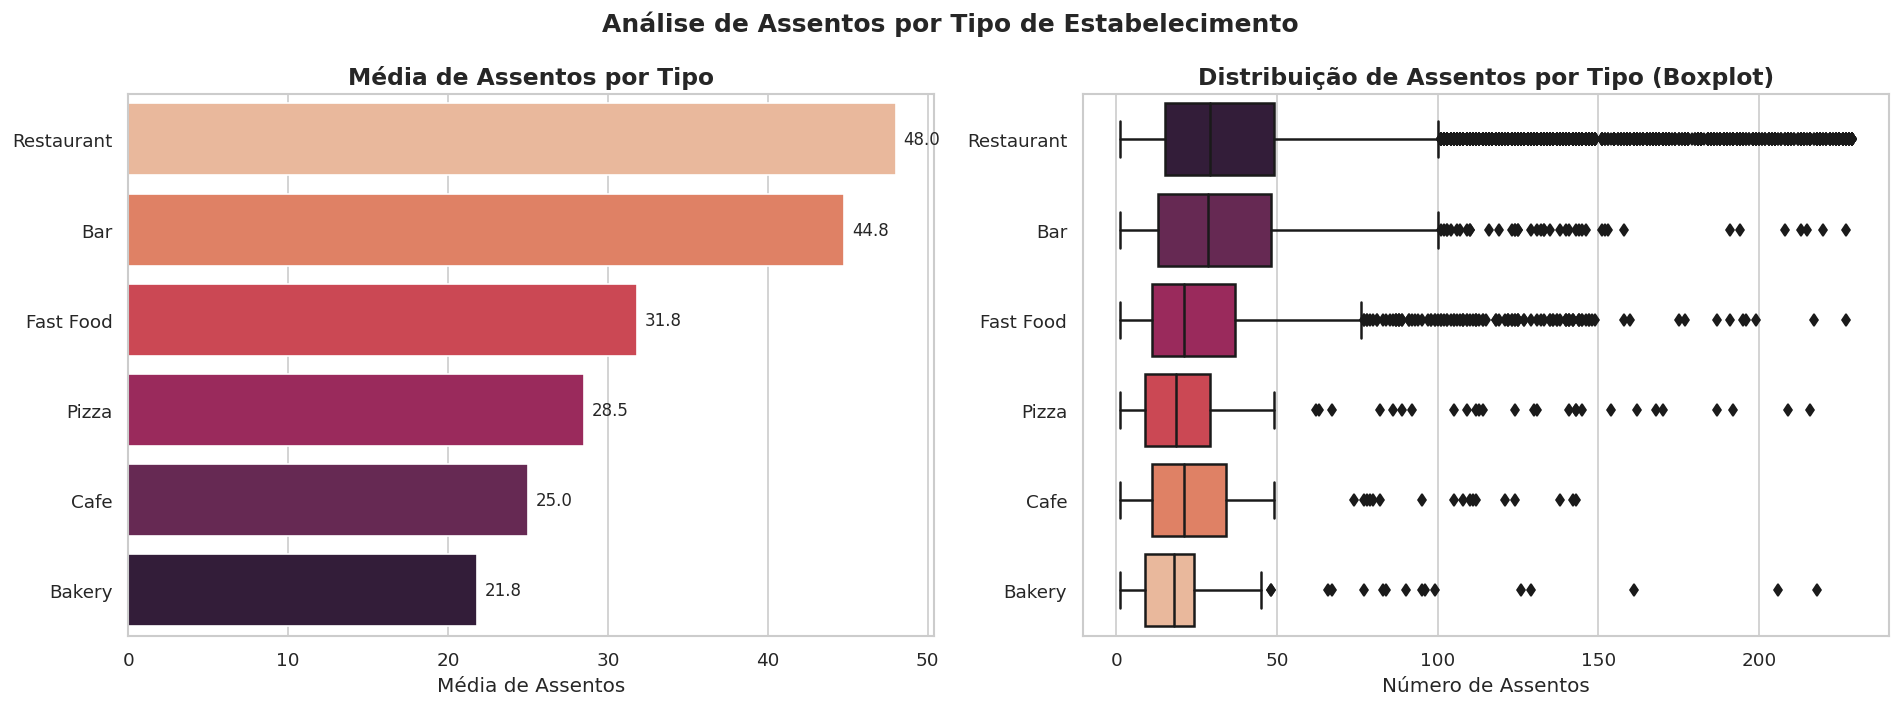

object_type  avg_seats
 Restaurant       48.0
        Bar       44.8
  Fast Food       31.8
      Pizza       28.5
       Cafe       25.0
     Bakery       21.8


In [32]:
#Número Médio de Assentos por Tipo de Restaurante
# Assentos médios por tipo 
avg_seats = df.groupby('object_type')['number'].mean().sort_values(ascending=False).reset_index()
avg_seats.columns = ['object_type', 'avg_seats']
avg_seats['avg_seats'] = avg_seats['avg_seats'].round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barras
palette = sns.color_palette('rocket', len(avg_seats))
sns.barplot(data=avg_seats, x='avg_seats', y='object_type',
            palette=palette[::-1], ax=axes[0])
axes[0].set_title('Média de Assentos por Tipo', fontweight='bold')
axes[0].set_xlabel('Média de Assentos')
axes[0].set_ylabel('')
for i, row in avg_seats.iterrows():
    axes[0].text(row['avg_seats'] + 0.5, i, f"{row['avg_seats']}", va='center', fontsize=10)

# Boxplot da distribuição
order = avg_seats['object_type'].tolist()
sns.boxplot(data=df, x='number', y='object_type', order=order,
            palette='rocket', ax=axes[1])
axes[1].set_title('Distribuição de Assentos por Tipo (Boxplot)', fontweight='bold')
axes[1].set_xlabel('Número de Assentos')
axes[1].set_ylabel('')

plt.suptitle('Análise de Assentos por Tipo de Estabelecimento', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(avg_seats.to_string(index=False))

Restaurantes tradicionais e Bares têm, em média, mais assentos. Juice Bars e Ice Cream têm menos.
O nosso conceito de cafeteria se enquadra em um segmento de porte médio (~30-50 assentos), adequado para o modelo de negócio.


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Média de assentos caclulada.
</div>

In [33]:
#Extraindo o Nome da Rua do Endereço
# Extração da rua com regex 
# Formato: '1234 Nome Da Rua, Los Angeles, CA'

df['street'] = df['address'].str.extract(r'^\d+\s+(.+)$')

print('Exemplo de extração:')
print(df[['address', 'street']].head(8))
print(f'\nRuas únicas identificadas: {df["street"].nunique()}')
print(f'Valores nulos na coluna street: {df["street"].isnull().sum()}')

Exemplo de extração:
                   address              street
0   3708 N EAGLE ROCK BLVD   N EAGLE ROCK BLVD
1        100 WORLD WAY 120       WORLD WAY 120
2  6801 HOLLYWOOD BLVD 253  HOLLYWOOD BLVD 253
3       1814 W SUNSET BLVD       W SUNSET BLVD
4       2100 ECHO PARK AVE       ECHO PARK AVE
5      10004 NATIONAL BLVD       NATIONAL BLVD
6        100 WORLD WAY 126       WORLD WAY 126
7    3500 W 6TH ST STE 226    W 6TH ST STE 226

Ruas únicas identificadas: 3069
Valores nulos na coluna street: 8


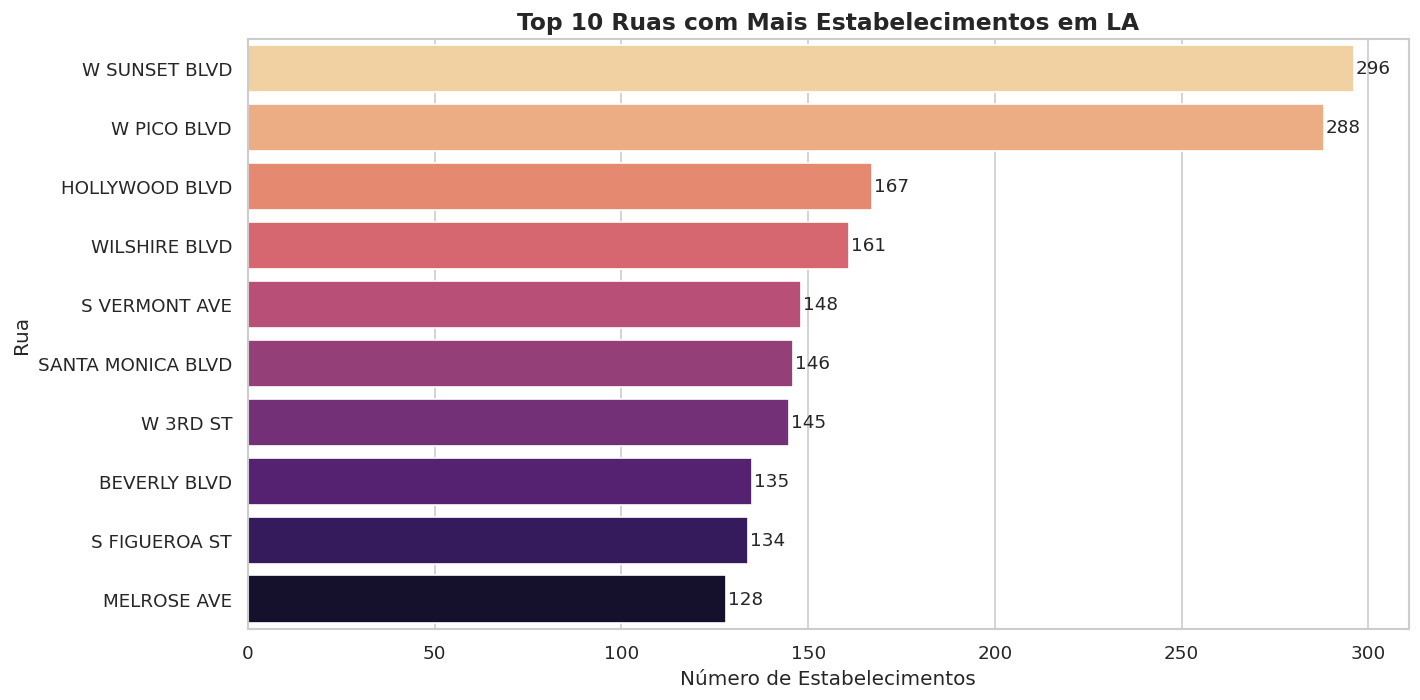

           street  count
    W SUNSET BLVD    296
      W PICO BLVD    288
   HOLLYWOOD BLVD    167
    WILSHIRE BLVD    161
    S VERMONT AVE    148
SANTA MONICA BLVD    146
         W 3RD ST    145
     BEVERLY BLVD    135
    S FIGUEROA ST    134
      MELROSE AVE    128


In [34]:
# Top 10 ruas 
top10_streets = df['street'].value_counts().head(10).reset_index()
top10_streets.columns = ['street', 'count']

fig, ax = plt.subplots(figsize=(12, 6))
bars = sns.barplot(data=top10_streets, x='count', y='street',
                   palette='magma_r', ax=ax)
ax.set_title('Top 10 Ruas com Mais Estabelecimentos em LA', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de Estabelecimentos')
ax.set_ylabel('Rua')
for i, row in top10_streets.iterrows():
    ax.text(row['count'] + 0.5, i, str(row['count']), va='center', fontsize=11)
plt.tight_layout()
plt.show()

print(top10_streets.to_string(index=False))

As ruas mais movimentadas concentram dezenas de estabelecimentos, indicando alta densidade comercial.
Sunset Blvd, Wilshire Blvd e Hollywood Blvd lideram — são corredores turísticos e comerciais consolidados.

Total de ruas identificadas:              3069
Ruas com apenas 1 estabelecimento:        2442
Percentual sobre o total de ruas:         79.6%


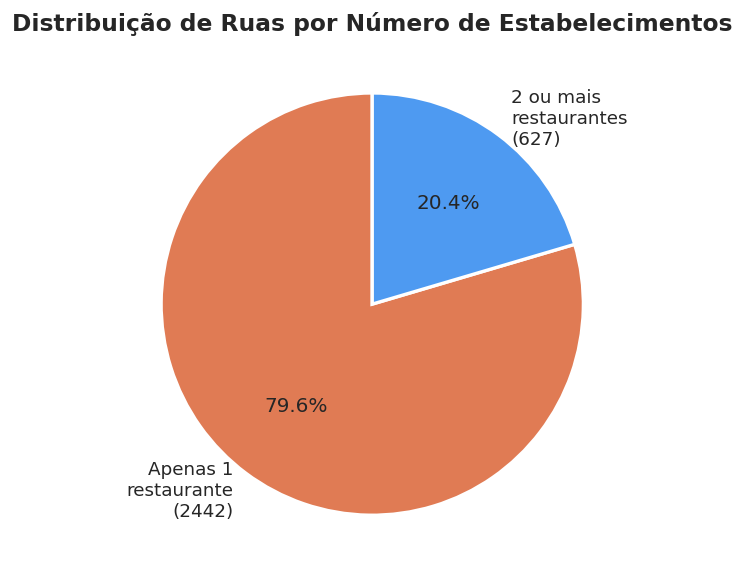

In [35]:
# Ruas com apenas 1 estabelecimento
street_counts = df['street'].value_counts()
single_restaurant_streets = (street_counts == 1).sum()

print(f'Total de ruas identificadas:              {len(street_counts)}')
print(f'Ruas com apenas 1 estabelecimento:        {single_restaurant_streets}')
print(f'Percentual sobre o total de ruas:         {single_restaurant_streets/len(street_counts)*100:.1f}%')

# Visualização
fig, ax = plt.subplots(figsize=(8, 5))
labels = [f'Apenas 1\nrestaurante\n({single_restaurant_streets})',
          f'2 ou mais\nrestaurantes\n({len(street_counts) - single_restaurant_streets})']
sizes = [single_restaurant_streets, len(street_counts) - single_restaurant_streets]
ax.pie(sizes, labels=labels, autopct='%1.1f%%',
       colors=['#e07b54', '#4e9af1'], startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Distribuição de Ruas por Número de Estabelecimentos', fontweight='bold')
plt.tight_layout()
plt.show()

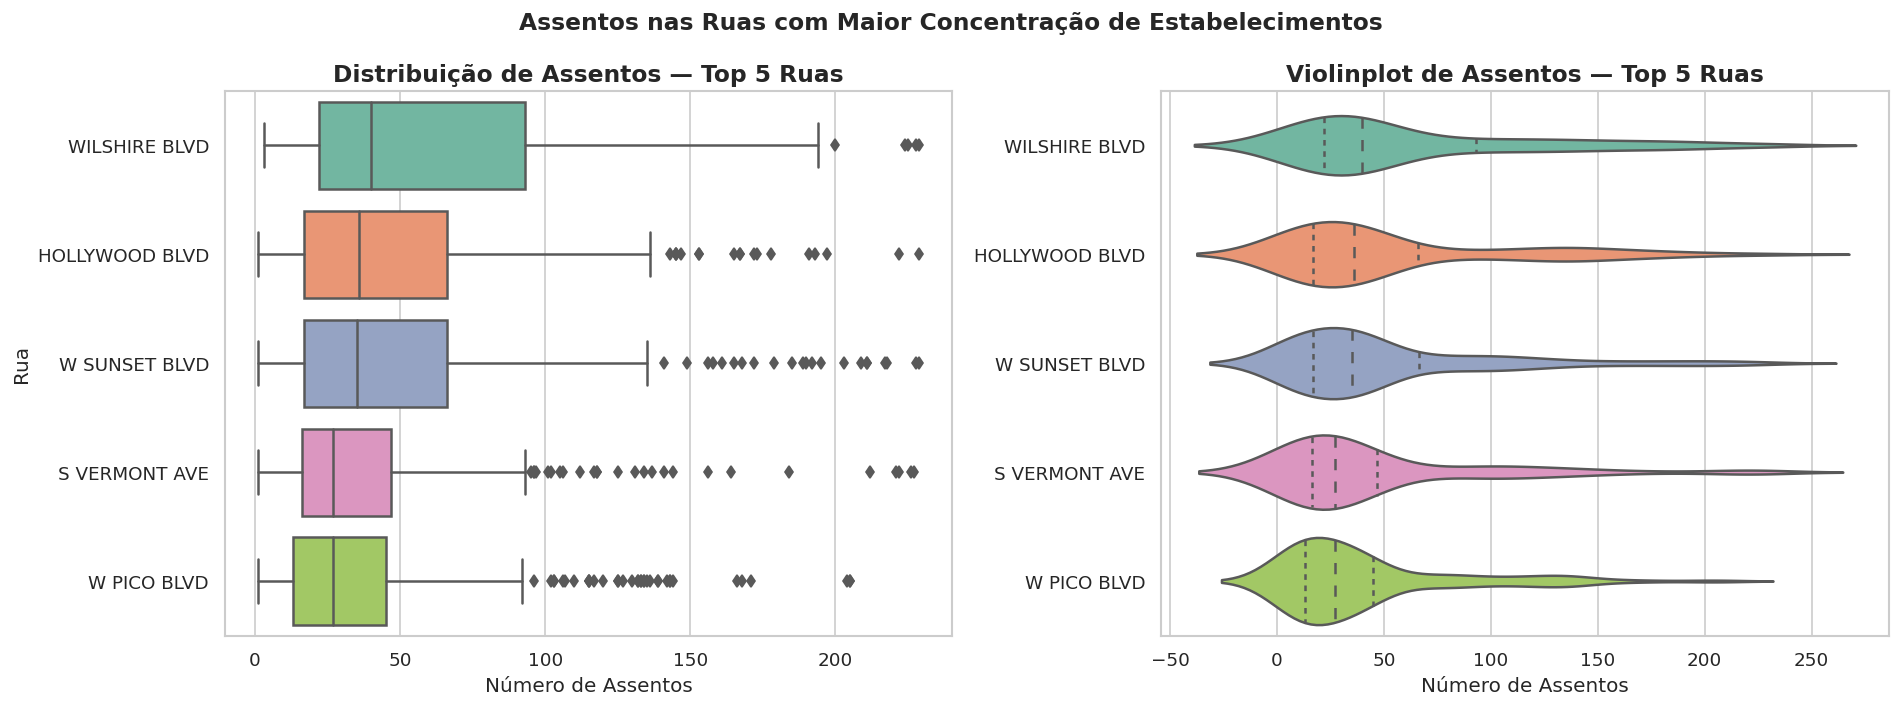

                count  mean   std  min   25%   50%   75%    max
street                                                         
HOLLYWOOD BLVD  167.0  53.7  53.5  1.0  17.0  36.0  66.0  229.0
S VERMONT AVE   148.0  45.9  51.0  1.0  16.2  27.0  47.0  227.0
W PICO BLVD     288.0  40.9  41.8  1.0  13.0  27.0  45.0  205.0
W SUNSET BLVD   296.0  50.9  50.5  1.0  17.0  35.0  66.2  229.0
WILSHIRE BLVD   161.0  62.1  57.5  3.0  22.0  40.0  93.0  229.0


In [36]:
# Distribuição de assentos nas top ruas
top5_streets = top10_streets['street'].head(5).tolist()
df_top5 = df[df['street'].isin(top5_streets)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot por rua
order = (df_top5.groupby('street')['number'].median()
         .sort_values(ascending=False).index.tolist())
sns.boxplot(data=df_top5, x='number', y='street', order=order,
            palette='Set2', ax=axes[0])
axes[0].set_title('Distribuição de Assentos — Top 5 Ruas', fontweight='bold')
axes[0].set_xlabel('Número de Assentos')
axes[0].set_ylabel('Rua')

# Violinplot
sns.violinplot(data=df_top5, x='number', y='street', order=order,
               palette='Set2', inner='quartile', ax=axes[1])
axes[1].set_title('Violinplot de Assentos — Top 5 Ruas', fontweight='bold')
axes[1].set_xlabel('Número de Assentos')
axes[1].set_ylabel('')

plt.suptitle('Assentos nas Ruas com Maior Concentração de Estabelecimentos',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(df_top5.groupby('street')['number'].describe().round(1))

Nas ruas mais movimentadas, há grande variabilidade de assentos. A mediana gira em torno de 50-70 assentos,
sugerindo que estabelecimentos de médio porte são o padrão nessas localidades. 
A presença de outliers indica algumas operações grandes (restaurantes âncora).

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

As manipulações solicitadas relativas ao endereço e análises correspondentes foram realizadas! Gráficos e conclusão estão presentes conforme solicitado.
</div>

### 2.10 Conclusão Geral e Recomendações para Investidores

**Contexto:** Abertura de uma cafeteria com garçons robôs em Los Angeles.

#### Tipo de Estabelecimento Recomendado: **Café**
- Cafés representam ~15% do mercado — nicho consolidado, mas com menos saturação que fast food.
- Têm alta proporção de independentes (~65%), indicando que o mercado aceita novos entrantes.
- O diferencial tecnológico (garçons robôs) é mais impactante em cafés, onde a experiência do cliente é central.

#### Número de Assentos Recomendado: **30 a 50 assentos**
- Alinha-se à mediana do segmento nas ruas mais movimentadas.
- É suficiente para operar com eficiência e proporcionar boa experiência sem exigir espaço excessivo.
- Permite escalar o modelo para uma rede sem custo proibitivo por unidade.

#### Localização Sugerida
- Ruas como Sunset Blvd, Wilshire Blvd e Hollywood Blvd têm alta densidade e tráfego de clientes potenciais.
- Ruas com muitos concorrentes têm visibilidade, mas exigem diferenciação clara — o conceito robótico entrega isso.

#### Potencial para Rede
- As redes bem-sucedidas em LA no segmento de cafés seguem o padrão: **muitas unidades com número moderado de assentos**.
- Com o conceito de garçons robôs padronizável, a replicação é viável: o modelo operacional pode ser clonado unidade a unidade.
- Recomenda-se iniciar com **1-2 unidades piloto** em localizações premium para validar o conceito antes de expandir.

#### Veredicto para Investidores
O mercado de cafés em LA é receptivo a novos modelos. A diferenciação tecnológica reduz o risco de desaparecimento com o fim da novidade, pois a eficiência operacional dos robôs mantém competitividade em custo no longo prazo.

Presentation: <https://plequipamentos-my.sharepoint.com/:p:/g/personal/yoliveira_plequipamentos_com_br/IQDUkwcCtATeS4DvUxlLpJ2oAdlY3XYagV0xLsTUpn2-YZ4?e=2zxqDR>